<a href="https://colab.research.google.com/github/sfaizenn/AnalisisNumerikPerahu/blob/main/25083010009_Sandi_Fadia_Aizena_Analisis_Numerik_Perahu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama: Sandi Fadia Aizena**

**NPM: 25083010009**

**Mata Kuliah: Analisis Numerik (A)**

**Link Github:** https://github.com/sfaizenn/AnalisisNumerikPerahu


Pada tugas ini dilakukan perhitungan volume kedua lambung kapal berdasarkan gambar dan data yang diberikan. **Ketentuan yang digunakan dalam perhitungan:**
1. Satu dash-kosong = 5 + 5 cm = 10 cm.
2. Lantai kapal dianggap datar dan tidak memiliki keel.
3. Tampak depan kapal dianggap berbentuk persegi panjang.
4. Volume reserve buoyancy tidak dihitung.

### **Import Library dan Memasukkan Gambar**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 69.5 MB/s eta 0:00:00


Saving perahu.pdf to perahu.pdf


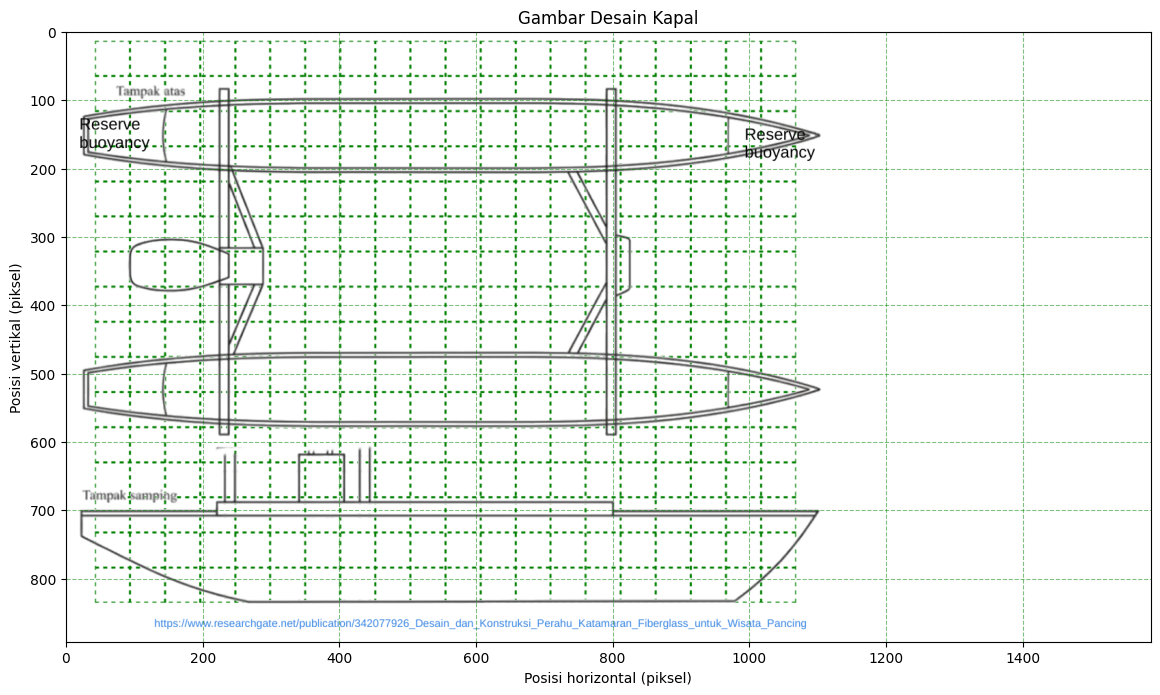

Ukuran gambar: 1588 x 893


In [1]:
!pip install -q pymupdf
import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

nama_file = next(iter(uploaded))

pdf = fitz.open(nama_file)
halaman = pdf[0]

gambar = halaman.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)

gambar_array = np.frombuffer(
    gambar.samples, dtype=np.uint8
).reshape(gambar.height, gambar.width, 3)

plt.figure(figsize=(14, 8))
plt.imshow(gambar_array)
plt.title("Gambar Desain Kapal")
plt.xlabel("Posisi horizontal (piksel)")
plt.ylabel("Posisi vertikal (piksel)")
plt.grid(color="green", linestyle="--", alpha=0.5)
plt.show()

print("Ukuran gambar:", gambar.width, "x", gambar.height)

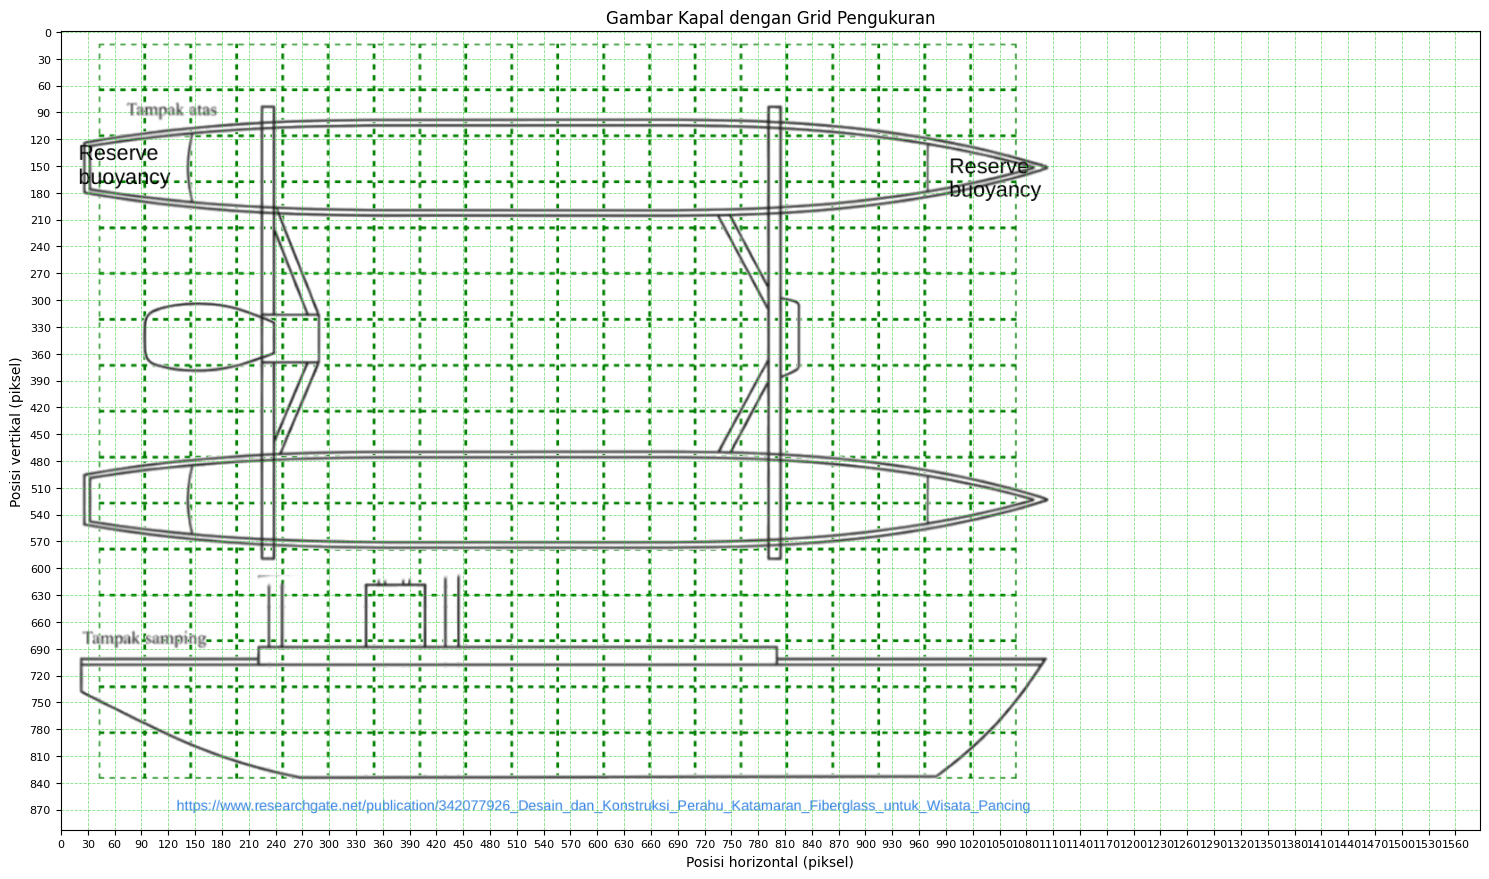

In [2]:
# Menentukan jarak grid dalam piksel
ukuran_grid = 30  # sesuaikan dengan ukuran kotak pada gambar

tinggi, lebar = gambar_array.shape[:2]

fig, ax = plt.subplots(figsize=(15, 9))

ax.imshow(gambar_array)

# Mengatur garis grid
ax.set_xticks(np.arange(0, lebar, ukuran_grid))
ax.set_yticks(np.arange(0, tinggi, ukuran_grid))

ax.grid(
    True,
    color="limegreen",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6
)

# Mengatur posisi label
ax.tick_params(axis="both", labelsize=8)

ax.set_title("Gambar Kapal dengan Grid Pengukuran")
ax.set_xlabel("Posisi horizontal (piksel)")
ax.set_ylabel("Posisi vertikal (piksel)")

plt.tight_layout()
plt.show()

### **Menentukan titik dan jarak**

In [3]:
# 1 dash-kosong = 5 + 5 cm = 10 cm
h = 10  # jarak antar titik dalam cm

# Posisi titik dari x = 0 sampai x = 200 cm
x = np.arange(0, 201, 10)

print("Jarak antar titik =", h, "cm")
print("Jumlah titik =", len(x))
print("Panjang lambung =", x[-1], "cm")

Jarak antar titik = 10 cm
Jumlah titik = 21
Panjang lambung = 200 cm


Berdasarkan skala pada gambar, jarak antar titik ditentukan sebesar 10 cm. Titik pengamatan dimulai dari $x=0$ cm hingga $x=200$ cm, sehingga diperoleh 21 titik dengan 20 interval.

### **Memasukkan data lebar lambung**

Lebar lambung \(B(x)\) pada setiap titik pengamatan diperoleh dari hasil pembacaan gambar. Nilai tersebut digunakan untuk menunjukkan perubahan lebar lambung sepanjang kapal dan dinyatakan dalam satuan cm. Terdapat 21 data lebar yang sesuai dengan 21 titik pengamatan yang telah ditentukan sebelumnya.

In [4]:
# Lebar lambung B(x) dalam cm
B = np.array([
    9.78, 8.77, 17.88, 19.22, 19.56,
    19.56, 19.56, 19.56, 19.56, 19.56,
    19.56, 19.56, 19.56, 19.56, 19.56,
    18.55, 17.20, 14.84, 11.13, 8.43,
    6.41
])

print("Jumlah data lebar =", len(B))

Jumlah data lebar = 21


Terdapat 21 data lebar lambung yang sesuai dengan 21 titik pengamatan, sehingga data siap digunakan untuk perhitungan luas penampang lambung.

### **Memasukkan data tinggi lambung**

Data tinggi atau kedalaman lambung \(H(x)\) dimasukkan berdasarkan hasil pengukuran pada 21 titik pengamatan. Data dinyatakan dalam satuan cm dan akan digunakan bersama data lebar lambung untuk menghitung luas penampang.

In [5]:
# Tinggi/kedalaman lambung H(x) dalam cm
H = np.array([
     8.43, 13.15, 17.88, 21.59, 24.28,
    25.30, 25.30, 25.30, 25.30, 25.30,
    25.30, 25.30, 25.30, 25.30, 25.30,
    25.30, 25.30, 25.30, 25.30, 18.89,
     8.09
])

print("Jumlah data tinggi =", len(H))

Jumlah data tinggi = 21


Terdapat 21 data tinggi lambung yang sesuai dengan 21 titik pengamatan, sehingga data siap digunakan dalam perhitungan luas penampang.

### **Membuat tabel data**

Data titik pengamatan, lebar lambung \(B(x)\), dan tinggi lambung \(H(x)\) digabungkan ke dalam satu tabel agar hubungan antara posisi \(x\), lebar, dan tinggi lambung dapat dilihat dengan lebih mudah.

In [6]:
data = pd.DataFrame({
    'x (cm)': x,
    'Lebar B (cm)': B,
    'Tinggi H (cm)': H
})

data

,x (cm),Lebar B (cm),Tinggi H (cm)
0,0,9.78,8.43
1,10,8.77,13.15
2,20,17.88,17.88
3,30,19.22,21.59
4,40,19.56,24.28
5,50,19.56,25.30
6,60,19.56,25.30
7,70,19.56,25.30
8,80,19.56,25.30
9,90,19.56,25.30


Tabel berhasil dibuat dan memuat data \(x\), lebar lambung, serta tinggi lambung pada seluruh 21 titik pengamatan. Data ini selanjutnya dapat digunakan untuk menghitung luas penampang pada setiap titik.

### **Menghitung luas setiap penampang**

Luas setiap penampang dihitung dengan mengalikan lebar lambung $B(x)$ dan tinggi lambung $H(x)$. Penampang lambung dianggap berbentuk persegi panjang, sehingga luas penampang dihitung menggunakan rumus:

$$
A(x) = B(x) \times H(x)
$$

In [7]:
# Luas penampang setiap titik
A = B * H

data['Luas Penampang A (cm²)'] = A

data

,x (cm),Lebar B (cm),Tinggi H (cm),Luas Penampang A (cm²)
0,0,9.78,8.43,82.4454
1,10,8.77,13.15,115.3255
2,20,17.88,17.88,319.6944
3,30,19.22,21.59,414.9598
4,40,19.56,24.28,474.9168
5,50,19.56,25.30,494.8680
6,60,19.56,25.30,494.8680
7,70,19.56,25.30,494.8680
8,80,19.56,25.30,494.8680
9,90,19.56,25.30,494.8680


Berdasarkan hasil perhitungan, luas penampang pada setiap titik berbeda-beda karena lebar dan tinggi lambung berubah sepanjang kapal. Luas penampang semakin besar dari bagian awal hingga mencapai nilai maksimum di bagian tengah, kemudian kembali mengecil menuju bagian akhir. Nilai luas penampang ini selanjutnya digunakan sebagai data dalam perhitungan volume lambung menggunakan metode Simpson 1/3.

### **Simpson 1/3**

Metode Simpson 1/3 digunakan untuk menghitung integral numerik berdasarkan data luas penampang pada setiap titik. Sebelum menerapkan metode tersebut, jumlah interval diperiksa terlebih dahulu. Metode Simpson 1/3 dapat digunakan apabila jumlah interval merupakan bilangan genap.

In [8]:
n = len(A) - 1

# Memastikan jumlah interval genap
if n % 2 != 0:
    print("Jumlah interval harus genap")
else:
    print("Jumlah interval =", n)
    print("Metode Simpson 1/3 dapat digunakan")

Jumlah interval = 20
Metode Simpson 1/3 dapat digunakan


Terdapat 20 interval dari 21 titik pengamatan. Karena jumlah interval tersebut merupakan bilangan genap, maka syarat penggunaan metode Simpson 1/3 terpenuhi dan metode tersebut dapat digunakan untuk menghitung volume lambung kapal.

### **Menghitung volume satu lambung**

Data luas penampang yang telah diperoleh digunakan untuk menghitung volume satu lambung dengan metode Simpson 1/3. Rumus yang digunakan adalah:

$$
V \approx \frac{h}{3}
\left[
A_0 + A_n
+ 4\sum_{\text{indeks ganjil}} A_i
+ 2\sum_{\text{indeks genap}} A_i
\right]
$$

dengan $h=10$ cm sebagai jarak antar titik, $A_i$ sebagai luas penampang pada titik ke-$i$, dan $n=20$ sebagai jumlah interval.

In [9]:
# Metode Simpson 1/3

jumlah_ganjil = np.sum(A[1:-1:2])
jumlah_genap = np.sum(A[2:-1:2])

V_satu = (h / 3) * (
    A[0]
    + A[-1]
    + 4 * jumlah_ganjil
    + 2 * jumlah_genap
)

print("Jumlah A indeks ganjil =", jumlah_ganjil)
print("Jumlah A indeks genap  =", jumlah_genap)
print()
print(f"Volume satu lambung = {V_satu:.3f} cm³")

Jumlah A indeks ganjil = 4008.6349999999993
Jumlah A indeks genap  = 3985.7002

Volume satu lambung = 80467.476 cm³


Berdasarkan perhitungan dengan metode Simpson 1/3, diperoleh volume satu lambung sebesar 80.467,476 cm³. Nilai tersebut diperoleh dari integrasi numerik luas penampang pada 21 titik pengamatan dengan jarak antar titik sebesar 10 cm.

### **Menghitung volume dua lambung**

Volume kapal terdiri dari dua lambung yang dianggap memiliki bentuk dan ukuran yang sama. Oleh karena itu, volume total kapal diperoleh dengan menjumlahkan volume kedua lambung atau mengalikan volume satu lambung dengan 2.

Rumus yang digunakan adalah:

$$
V_{\text{total}} = 2V_{\text{satu}}
$$

dengan $V_{\text{satu}}$ merupakan volume satu lambung yang telah dihitung menggunakan metode Simpson 1/3.


In [10]:
# Kapal memiliki dua lambung

V_total = 2 * V_satu

print(f"Volume satu lambung = {V_satu:.3f} cm³")
print(f"Volume dua lambung  = {V_total:.3f} cm³")

Volume satu lambung = 80467.476 cm³
Volume dua lambung  = 160934.951 cm³


Karena kapal memiliki dua lambung dengan ukuran yang sama, volume total diperoleh dengan mengalikan volume satu lambung dengan 2. Hasil perhitungan menunjukkan volume total kedua lambung sebesar 160.934,951 cm³.

### **Konversi satuan**

Volume yang diperoleh dari perhitungan sebelumnya masih dalam satuan cm³. Untuk memudahkan interpretasi hasil, volume tersebut dikonversikan ke satuan liter dan m³.

Hubungan konversi yang digunakan adalah:

$$
1\text{ liter}=1000\text{ cm}^3
$$

dan

$$
1\text{ m}^3=1.000.000\text{ cm}^3
$$

Sehingga:

$$
V_{\text{liter}}=\frac{V_{\text{total}}}{1000}
$$

$$
V_{\text{m}^3}=\frac{V_{\text{total}}}{1.000.000}
$$

In [11]:
# Konversi cm³ ke liter dan m³

V_liter = V_total / 1000
V_m3 = V_total / 1_000_000

print(f"Volume dua lambung = {V_total:.3f} cm³")
print(f"Volume dua lambung = {V_liter:.3f} liter")
print(f"Volume dua lambung = {V_m3:.6f} m³")

Volume dua lambung = 160934.951 cm³
Volume dua lambung = 160.935 liter
Volume dua lambung = 0.160935 m³


Berdasarkan hasil konversi, volume total kedua lambung adalah 160.934,951 cm³, yang setara dengan 160,935 liter atau 0,160935 m³. Ketiga nilai tersebut menunjukkan volume yang sama dalam satuan yang berbeda.

In [12]:
print("PERHITUNGAN VOLUME DUA LAMBUNG KAPAL")
print(f"Panjang lambung       : {x[-1]} cm")
print(f"Jarak antar titik     : {h} cm")
print(f"Jumlah interval       : {n}")
print(f"Volume satu lambung   : {V_satu:.3f} cm³")
print(f"Volume dua lambung    : {V_total:.3f} cm³")
print(f"Volume dua lambung    : {V_m3:.6f} m³")
print(f"Volume dua lambung    : {V_liter:.3f} liter")

PERHITUNGAN VOLUME DUA LAMBUNG KAPAL
Panjang lambung       : 200 cm
Jarak antar titik     : 10 cm
Jumlah interval       : 20
Volume satu lambung   : 80467.476 cm³
Volume dua lambung    : 160934.951 cm³
Volume dua lambung    : 0.160935 m³
Volume dua lambung    : 160.935 liter


### **Kesimpulan**

Berdasarkan perhitungan yang telah dilakukan, volume dua lambung kapal ditentukan menggunakan metode integrasi numerik Simpson 1/3. Data yang digunakan terdiri dari 21 titik pengamatan dengan jarak antar titik sebesar 10 cm, sehingga diperoleh 20 interval. Pada setiap titik, data lebar dan tinggi lambung digunakan untuk menghitung luas penampang dengan pendekatan penampang berbentuk persegi panjang, yaitu $A(x)=B(x)\times H(x)$.

Hasil perhitungan luas penampang kemudian digunakan dalam metode Simpson 1/3 untuk memperoleh volume satu lambung. Dari hasil perhitungan diperoleh volume satu lambung sebesar **80.467,476 cm³**. Karena kapal memiliki dua lambung dengan ukuran yang sama, volume total kedua lambung diperoleh sebesar **160.934,951 cm³**.

Hasil tersebut setara dengan **160,935 liter** atau **0,160935 m³**. Dengan demikian, berdasarkan data dan metode numerik yang digunakan, volume total kedua lambung kapal adalah sebesar **0,160935 m³**.